In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from PIL import Image

In [2]:
class CFG:
    DATA_PATH = "/kaggle/input/datasets/daluanjali/vinbig-ass"
    CSV_PATH = os.path.join(DATA_PATH, "Data/train.csv")
    IMAGE_DIR = os.path.join(DATA_PATH, "images/train")

    IMG_SIZE = 512
    BATCH_SIZE = 16
    EPOCHS = 50
    LR = 1e-4
    NUM_CLASSES = 15
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    MODEL_NAME = "tf_efficientnet_b4"
    SEED = 42

In [3]:
df = pd.read_csv(CFG.CSV_PATH)

# Convert detection → classification
df_cls = df.groupby("image_id").first().reset_index()

class_mapping = df[['class_id', 'class_name']].drop_duplicates().sort_values('class_id')
class_dict = dict(zip(class_mapping.class_id, class_mapping.class_name))

train_df, val_df = train_test_split(
    df_cls,
    test_size=0.2,
    stratify=df_cls["class_id"],
    random_state=CFG.SEED
)

print("Train:", len(train_df), "Val:", len(val_df))

Train: 12000 Val: 3000


In [4]:
train_tfms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(p=0.3),
    A.GaussianBlur(p=0.2),
    A.CLAHE(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
class VinBigDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")
        image = np.array(Image.open(img_path).convert("RGB"))

        label = int(row["class_id"])

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label

In [6]:
class_counts = train_df["class_id"].value_counts().sort_index()
class_weights = 1.0 / class_counts

sample_weights = train_df["class_id"].map(class_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights.values,
    num_samples=len(sample_weights),
    replacement=True
)

In [7]:
train_dataset = VinBigDataset(train_df, CFG.IMAGE_DIR, train_tfms)
val_dataset = VinBigDataset(val_df, CFG.IMAGE_DIR, val_tfms)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)

In [8]:
model = timm.create_model(
    CFG.MODEL_NAME,
    pretrained=True,
    num_classes=CFG.NUM_CLASSES
)

model = model.to(CFG.DEVICE)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Unfreeze head
for param in model.get_classifier().parameters():
    param.requires_grad = True

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [9]:
weights = torch.tensor(class_weights.values, dtype=torch.float).to(CFG.DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)

In [10]:
scaler = torch.cuda.amp.GradScaler()

best_acc = 0

for epoch in range(CFG.EPOCHS):
    print(f"\nEpoch {epoch+1}/{CFG.EPOCHS}")

    # TRAIN
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(CFG.DEVICE), labels.to(CFG.DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        preds = torch.argmax(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, correct, total = 0, 0, 0

    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader):
            images, labels = images.to(CFG.DEVICE), labels.to(CFG.DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    val_acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val Acc: {val_acc:.4f} | F1: {f1:.4f}")

    scheduler.step()

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved")

/tmp/ipykernel_55/3251101407.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



Epoch 1/50


  0%|          | 0/750 [00:00<?, ?it/s]/tmp/ipykernel_55/3251101407.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 188/188 [00:59<00:00,  3.17it/s]


Train Acc: 0.0767
Val Acc: 0.0030 | F1: 0.0022
✅ Best model saved

Epoch 2/50


  0%|          | 0/750 [00:00<?, ?it/s]/tmp/ipykernel_55/3251101407.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 188/188 [01:00<00:00,  3.11it/s]


...

Train Acc: 0.1700
Val Acc: 0.0040 | F1: 0.0025

Epoch 49/50


  0%|          | 0/750 [00:00<?, ?it/s]/tmp/ipykernel_55/3251101407.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 188/188 [01:00<00:00,  3.11it/s]


Train Acc: 0.1784
Val Acc: 0.0043 | F1: 0.0022

Epoch 50/50


  0%|          | 0/750 [00:00<?, ?it/s]/tmp/ipykernel_55/3251101407.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 188/188 [01:00<00:00,  3.11it/s]


Train Acc: 0.1741
Val Acc: 0.0050 | F1: 0.0016


In [11]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=[class_dict[i] for i in range(15)]))


Classification Report:

                    precision    recall  f1-score   support

Aortic enlargement       0.00      0.00      0.00       226
       Atelectasis       0.00      0.17      0.00         6
     Calcification       0.02      0.17      0.03        18
      Cardiomegaly       0.00      0.00      0.00       176
     Consolidation       0.01      0.44      0.01         9
               ILD       0.01      0.05      0.02        22
      Infiltration       0.02      0.04      0.03        27
      Lung Opacity       0.14      0.02      0.04        50
       Nodule/Mass       0.00      0.00      0.00        44
      Other lesion       0.00      0.00      0.00        45
  Pleural effusion       0.05      0.02      0.03        48
Pleural thickening       0.00      0.00      0.00        99
      Pneumothorax       0.00      0.75      0.01         4
Pulmonary fibrosis       0.00      0.00      0.00       105
        No finding       0.00      0.00      0.00      2121

          acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 75.5 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Predicted: 2, True: 14


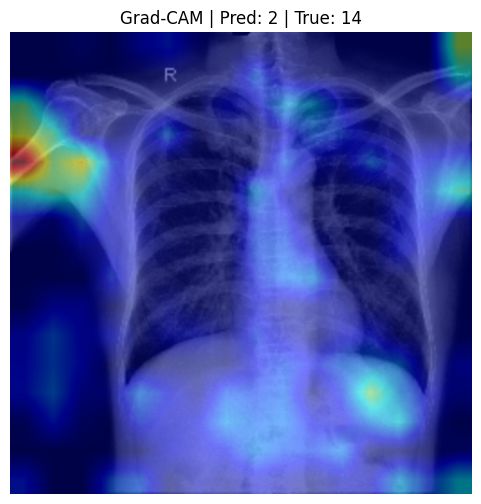

In [15]:
# ================================
# FINAL WORKING GRAD-CAM (FIXED)
# ================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()

# ✅ IMPORTANT: enable gradients
for p in model.parameters():
    p.requires_grad = True

# ✅ BEST STABLE LAYER (EfficientNet timm)
target_layers = [model.conv_head]

# ❌ DO NOT pass use_cuda
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# ================================
# Load sample
# ================================
image, label = val_dataset[0]
input_tensor = image.unsqueeze(0).to(CFG.DEVICE)

# ================================
# Forward pass
# ================================
output = model(input_tensor)

# ================================
# Select class
# ================================
target_class = output.argmax(dim=1).item()

print(f"Predicted: {target_class}, True: {label}")

# ================================
# Generate CAM
# ================================
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(target_class)]
)

# ================================
# Normalize image safely
# ================================
img_np = image.permute(1, 2, 0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

# ================================
# Overlay
# ================================
cam_image = show_cam_on_image(
    img_np,
    grayscale_cam[0],
    use_rgb=True
)

# ================================
# Plot
# ================================
plt.figure(figsize=(6,6))
plt.imshow(cam_image)
plt.title(f"Grad-CAM | Pred: {target_class} | True: {label}")
plt.axis("off")
plt.show()

In [18]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": CFG.EPOCHS,
}, "final_model.pth")

In [19]:
!pip freeze > requirements_mile3.txt